In [208]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import os
import pandas as pd
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# Download latest version
path = kagglehub.dataset_download("asaniczka/uk-optimal-product-price-prediction")
file_path = os.path.join(path, "amz_uk_price_prediction_dataset.csv")
df = pd.read_csv(file_path)

print("Path to dataset files:", path)
print("First 5 records:", df.head())

Path to dataset files: C:\Users\ranik\.cache\kagglehub\datasets\asaniczka\uk-optimal-product-price-prediction\versions\3
First 5 records:    uid        asin                                              title  stars  \
0    1  B09B96TG33  Echo Dot (5th generation, 2022 release) | Big ...    4.7   
1    2  B01HTH3C8S  Anker Soundcore mini, Super-Portable Bluetooth...    4.7   
2    3  B09B8YWXDF  Echo Dot (5th generation, 2022 release) | Big ...    4.7   
3    4  B09B8T5VGV  Echo Dot with clock (5th generation, 2022 rele...    4.7   
4    5  B09WX6QD65  Introducing Echo Pop | Full sound compact Wi-F...    4.6   

   reviews  price  isBestSeller  boughtInLastMonth        category  
0    15308  21.99         False                  0  Hi-Fi Speakers  
1    98099  23.99          True                  0  Hi-Fi Speakers  
2    15308  21.99         False                  0  Hi-Fi Speakers  
3     7205  31.99         False                  0  Hi-Fi Speakers  
4     1881  17.99         False     

### Part 1: Analyzing Best-Seller Trends Across Product Categories

**Objective**: Understand the relationship between product categories and their best-seller status.

1. **Crosstab Analysis**:
    - Create a crosstab between the product `category` and the `isBestSeller` status.
    
    - Are there categories where being a best-seller is more prevalent? 
    	
    	*Hint: one option is to calculate the proportion of best-sellers for each category and then sort the categories based on this proportion in descending order.*


2. **Statistical Tests**:
    - Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.
    - Compute Cramér's V to understand the strength of association between best-seller status and category.

3. **Visualizations**:
	- Visualize the relationship between product categories and the best-seller status using a stacked bar chart.

In [42]:
%matplotlib inline
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [65]:
ct_cat_bs = pd.crosstab(df['category'], df['isBestSeller']) #create a table category x isBestSeller
ct_cat_bs2 = ct_cat_bs.copy()
ct_cat_bs2["perc_bs"] = ct_cat_bs2[True]/ct_cat_bs2[True & False] #calculate the proportion of Bestseller for each category
ct_cat_bs2.sort_values('perc_bs', ascending = False).head(3) # sort for proportion of bestseller and return the first 3 values

#crosstab_cat_bests = pd.crosstab(df["category"], df["isBestSeller"], normalize="index")


isBestSeller,False,True,perc_bs
category,,,
Grocery,9008,556,0.061723
Smart Home Security & Lighting,98,6,0.061224
Health & Personal Care,9017,552,0.061218


In [ ]:
def chi_square_report(crosstab_result, round_expected=2, show=False):
    """
    Return all the values in an ordered manner
    """
    chi2, p, dof, expected = chi2_contingency(crosstab_result)

    expected_df = pd.DataFrame(
        expected,
        index=crosstab_result.index,
        columns=crosstab_result.columns
    ).round(round_expected)

    comparison = pd.concat(
        [crosstab_result.copy(), expected_df],
        keys=["Observed", "Expected"]
    )

    summary = pd.DataFrame({
        "Metric": ["Chi-square", "p-value", "Degrees of freedom"],
        "Value": [chi2, p, dof]
    })

    if show:
        print(summary)
        print(comparison)

    return summary, comparison

In [ ]:
# assessing the association between variables in using the chi-square test method
chi_square_report(ct_cat_bs) 

(               Metric         Value
 0          Chi-square  36540.202701
 1             p-value      0.000000
 2  Degrees of freedom    295.000000,
 isBestSeller                                                   False    True 
          category                                                            
 Observed 3D Printers                                          247.00     1.00
          3D Printing & Scanning                              4065.00     2.00
          Abrasive & Finishing Products                        245.00     5.00
          Action Cameras                                      1696.00     1.00
          Adapters                                             251.00     3.00
          Agricultural Equipment & Supplies                   8421.00   109.00
          Alexa Built-In Devices                               106.00     1.00
          Art & Craft Supplies                                 253.00     5.00
          Arts & Crafts                                      

In [ ]:
# Computing the association between variables in using the "cramer" method
association(ct_cat_bs, method='cramer')

0.1222829439760564

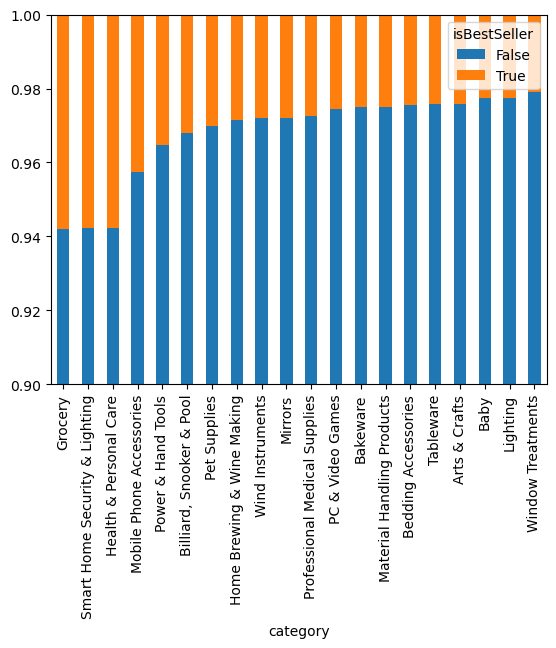

In [ ]:
crosstab_cat_bests = pd.crosstab(df["category"], df["isBestSeller"], normalize="index") #make frequencies relative

#sort and return the first 20 categories with the best bestseller ratio and plot the results
crosstab_cat_bests.sort_values(by=True, ascending=False)[:20].plot(kind='bar', stacked=True)

#improve readability zooming at the  [0.9 ; 1] interval of y axis (that shows the frequencies ratios)
plt.ylim(0.9, 1) 
plt.show()


### Part 2: Product Prices and Ratings Across Categories and Brands

**Objective**: Investigate how different product categories influence product prices.

0. **Preliminary Step: Remove outliers in product prices.**

	For this purpose, we can use the IQR (Interquartile Range) method. Products priced below the first quartile minus 1.5 times the IQR or above the third quartile plus 1.5 times the IQR will be considered outliers and removed from the dataset. The next steps will be done with the dataframe without outliers.
	
	*Hint: you can check the last Check For Understanding at the end of the lesson EDA Bivariate Analysis for a hint on how to do this.*



In [87]:
def outlier_slayer(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    # Define bounds for the outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify the outliers
    outliers = data[(data < lower_bound) | (data > upper_bound)]

    return outliers

In [91]:
data = df["price"]
outliers = outlier_slayer(data)

In [111]:
df2 = df[df["price"].isin(outliers) == False]
print(f"df: {len(df)}, outliers:{len(outliers)}, df after removal: {len(df2)}")

df: 2443651, outliers:327688, df after removal: 2115963


1. **Violin Plots**:
    - Use a violin plot to visualize the distribution of `price` across different product `categories`. Filter out the top 20 categories based on count for better visualization.
    - Which product category tends to have the highest median price? Don't filter here by top categories.

In [141]:
top_categories = df2.category.value_counts()[:20].reset_index()
top_categories = top_categories["category"].tolist()
df2_top_cat = df2[df2["category"].isin(top_categories)]

In [ ]:
order = (
    df2_top_cat
    .groupby("category")["price"]
    .median()
    .sort_values(ascending=False) 
    .index
)

C:\Users\ranik\AppData\Local\Temp\ipykernel_20088\107010753.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df2_top_cat, order = order, x="price", y="category", palette="coolwarm")


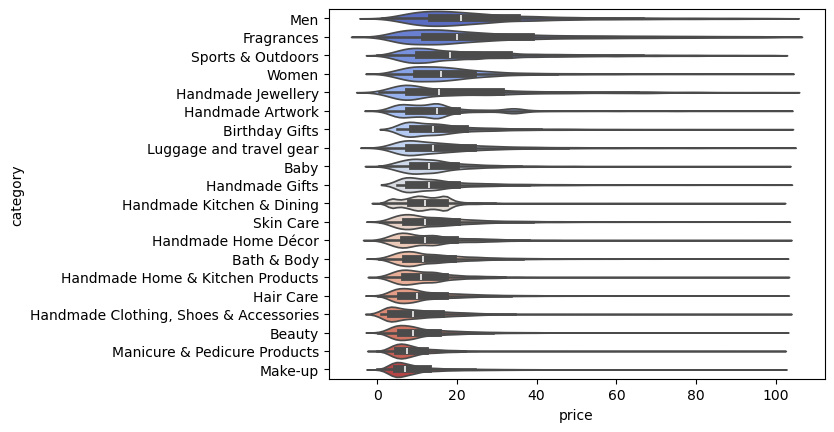

In [145]:
sns.violinplot(data=df2_top_cat, order = order, x="price", y="category", palette="coolwarm")
plt.show()

In [155]:
#product category with the highest median
order_by_median = df2.groupby("category")["price"].median().sort_values(ascending=False)[:20].index

C:\Users\ranik\AppData\Local\Temp\ipykernel_20088\1196765339.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df2, order = order_by_median, x="price", y="category", palette="coolwarm")


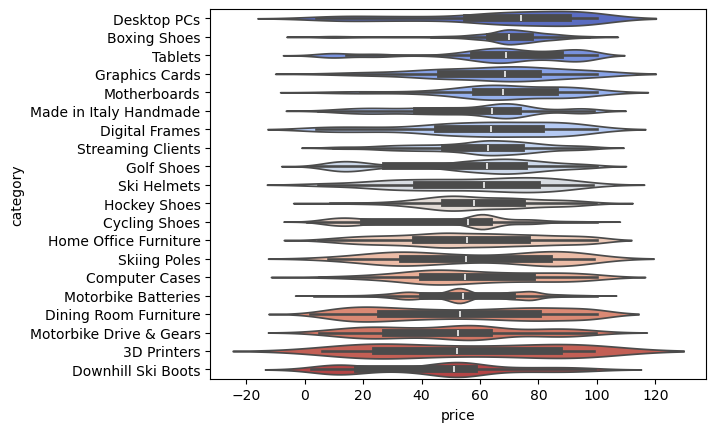

In [156]:
sns.violinplot(data=df2, order = order_by_median, x="price", y="category", palette="coolwarm")
plt.show()

2. **Bar Charts**:
    - Create a bar chart comparing the average price of products for the top 10 product categories (based on count).
    - Which product category commands the highest average price? Don't filter here by top categories.

In [186]:
top10_by_count = df2.category.value_counts()[:10].index #calculate the top 10 product categories by count
top10_by_count

Index(['Sports & Outdoors', 'Beauty', 'Bath & Body',
       'Manicure & Pedicure Products',
       'Handmade Clothing, Shoes & Accessories', 'Make-up', 'Skin Care',
       'Hair Care', 'Birthday Gifts', 'Handmade Gifts'],
      dtype='object', name='category')

In [187]:
df3 = df2[df2["category"].isin(top10_by_count)] #create a new dataset with only the top 10 categories

In [188]:
order_by_avg = df3.groupby("category")["price"].mean().sort_values(ascending=False).index

C:\Users\ranik\AppData\Local\Temp\ipykernel_20088\1621547345.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


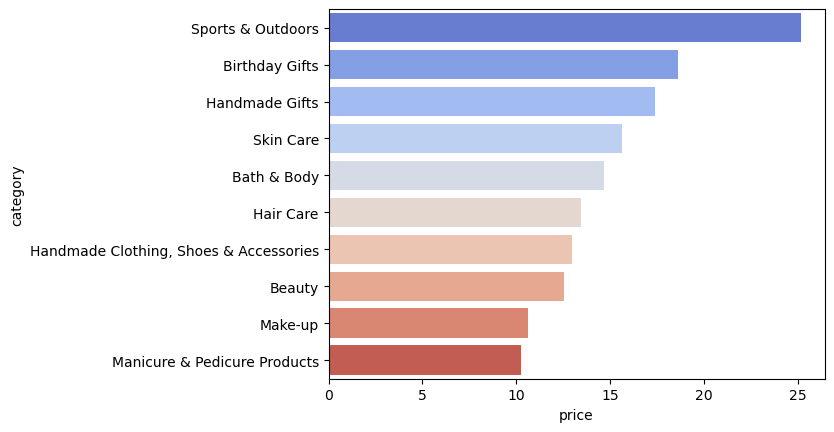

In [189]:
# Plotting a bar plot to visualize the average 'price' for each 'category', using the "coolwarm" color palette
sns.barplot(
    data=df3, 
    estimator= "mean", #min, mean, median etc
    x="price", 
    y="category", 
    order = order_by_avg,
    palette="coolwarm", 
    errorbar=None)
plt.show()

3. **Box Plots**:
    - Visualize the distribution of product `ratings` based on their `category` using side-by-side box plots. Filter out the top 10 categories based on count for better visualization.
    - Which category tends to receive the highest median rating from customers? Don't filter here by top categories.

C:\Users\ranik\AppData\Local\Temp\ipykernel_20088\2500989392.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df3, x="stars", y="category", palette="coolwarm", legend=True)


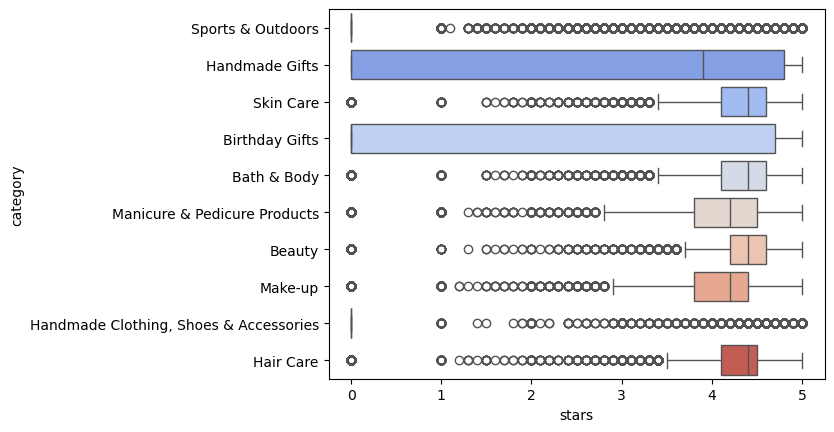

In [192]:
sns.boxplot(data=df3, x="stars", y="category", palette="coolwarm", legend=True)
plt.show()

In [198]:
top_cat_x_median_rate = df2.groupby("category")["stars"].median().sort_values(ascending=False)[:1].index
category = top_cat_x_median_rate[0]

C:\Users\ranik\AppData\Local\Temp\ipykernel_20088\1483302521.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df2[df2["category"]==category], x="stars", y="category", palette="coolwarm", legend=True)


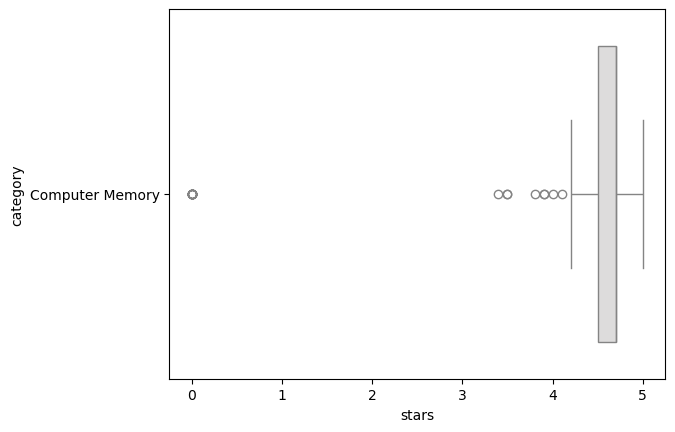

In [200]:
sns.boxplot(data=df2[df2["category"]==category], x="stars", y="category", palette="coolwarm", legend=True)
plt.show()

### Part 3: The Interplay Between Product Prices and Ratings

**Objective**: Analyze how product ratings (`stars`) correlate with product prices.

1. **Correlation Coefficients**:
    - Calculate the correlation coefficient between `price` and `stars`.
    - Is there a significant correlation between product price and its rating?

In [205]:
r_pearson = round(float(df2["price"].corr(df2["stars"], method="pearson")), 2)
r_spearman = round(float(df2["price"].corr(df2["stars"], method="spearman")), 2)
print(f"pearson correlation coefficient: {r_pearson}\nspearman correlation coefficient: {r_spearman}")

pearson correlation coefficient: -0.08
spearman correlation coefficient: -0.07


both the coefficient highlight a very weak, almost absent, negative correlation

2. **Visualizations**:
    - Use a scatter plot to visualize the relationship between product rating and price. What patterns can you observe?
    - Use a correlation heatmap to visualize correlations between all numerical variables.
    - Examine if product prices typically follow a normal distribution using a QQ plot. 

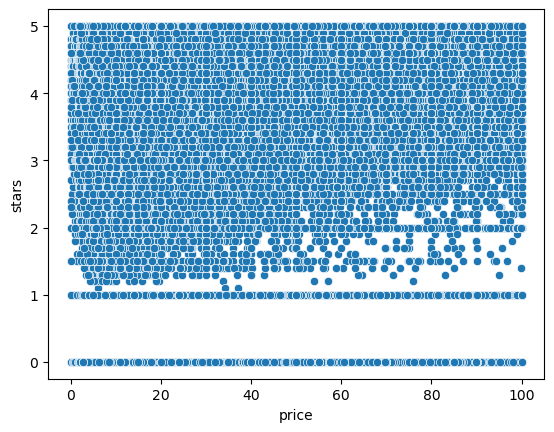

In [207]:
sns.scatterplot(data=df2, x='price', y='stars')
plt.show()

the scatterplot confirms the absent correlation between the two variables although we can also see that we can also see that starting from the price 40 it's less luckily for a product to receive low ratings

In [210]:
df2_num = df2.select_dtypes(include="number")

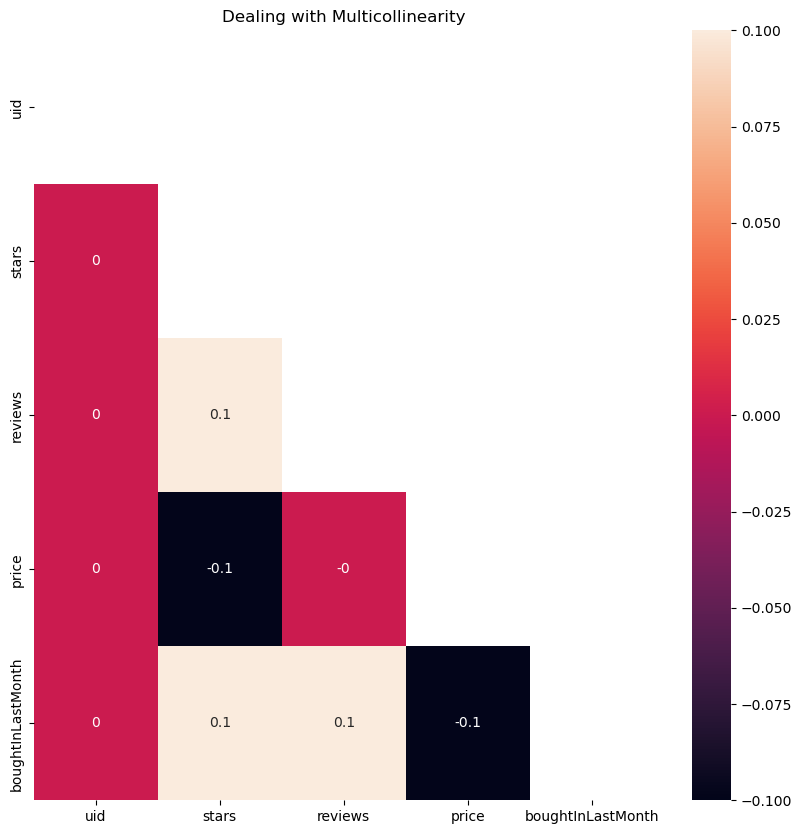

In [213]:
correlation_matrix = round(df2_num.corr(),1)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(10, 10))
sns.heatmap(correlation_matrix, mask=mask, annot=True)

plt.title("Dealing with Multicollinearity")
plt.show()

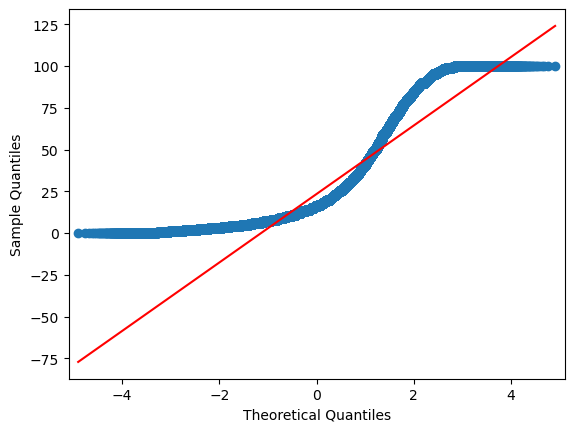

In [214]:
import statsmodels.api as sm

# Generating a Q-Q plot for 'SalePrice' to check if its distribution follows a normal distribution
sm.qqplot(df2['price'], line='s');
plt.show()